In [1]:
from atlas import load_atlas
atlas = load_atlas()

atlas.candidate_table()
atlas.missing_physics_table()
atlas.classify()


'Mixed-physics disk'

In [3]:
atlas.candidates

array([  5.12,   5.37,   5.86,   7.82,   7.94,   8.06,   8.19,   8.43,
        19.46,  22.53,  24.73,  45.08,  46.06,  46.3 ,  46.43,  46.55,
        46.79,  51.57,  51.7 ,  54.88,  55.99,  56.11,  56.23,  56.35,
        56.6 ,  62.24,  62.36,  68.36,  68.49,  68.73,  68.85,  68.98,
        69.1 ,  69.22,  76.94,  77.43,  83.32,  84.42,  84.54,  84.66,
        84.79,  85.03,  89.81,  92.88,  93.  , 100.84, 101.09, 101.21,
       101.33, 101.46, 101.58, 101.7 , 105.26, 105.5 , 105.62, 114.08,
       114.45, 125.36, 126.09, 126.21, 126.34, 126.46, 126.58, 126.83,
       146.44, 146.93, 147.05, 147.29, 166.29, 167.03, 167.27, 167.39,
       167.52, 167.76, 187.13, 187.62, 187.74, 187.98, 206.86, 207.72,
       207.84, 207.96, 208.21, 208.33, 227.57, 228.06, 228.18, 228.43,
       247.3 , 248.04, 248.28, 248.41, 248.65, 249.63, 249.75, 249.88])

In [4]:
atlas.candidate_table().head(10)

,radius_AU,compression,stability,v_drift,planet_forces,pressure,sigma,curvature,ring_width,survival,gap_mass,planet_mass_inversion,brightness
0,5.12,-0.068257,-0.023726,1.735915,0.001772,0.000086,0.195215,-0.034655,28.855945,-1.757869,0.000475,-0.120939,373.332520
1,5.37,-0.077574,-0.028347,1.833192,0.001785,0.000080,0.186300,-0.022628,44.193359,-1.859755,0.000495,-0.154208,533.049915
2,5.86,-0.103173,-0.042222,2.083869,0.001810,0.000071,0.170709,-0.045993,21.742606,-2.124281,0.000537,-0.150003,230.031176
3,7.82,-0.726540,-0.683841,5.521242,0.001915,0.000046,0.127895,23.313815,0.042893,-6.203168,0.000696,-0.277433,0.294279
4,7.94,-0.381887,-0.396970,2.607483,0.001922,0.000045,0.125921,15.853363,0.063078,-3.002530,0.000706,-0.131530,0.422784
5,8.06,0.414050,0.428477,-2.817757,0.001929,0.000044,0.124007,-17.252324,0.057963,-2.387350,0.000715,-0.139550,0.379678
6,8.19,0.715976,0.671592,-5.335237,0.001936,0.000043,0.122151,-22.491017,0.044462,-4.661710,0.000725,-0.265172,0.284726
7,8.43,0.489522,0.388778,-4.245136,0.001950,0.000041,0.118600,2.335354,0.428201,-3.854408,0.000744,-0.203836,2.623401
8,19.46,0.003049,0.000623,-0.067141,0.002797,0.000012,0.051382,0.000058,17173.638621,-0.063720,0.001461,0.531957,30002.997147
9,22.53,0.000028,0.000006,-0.000166,0.003137,0.000009,0.044393,0.000015,67709.367966,0.002976,0.001618,0.019447,94996.212362


In [5]:
atlas.missing_physics_table()

,zone,radius_AU
0,snowline,127.438719
1,dead_zone,250.0
2,drift_trap,8.186593
3,pressure_bump,5.0
4,gap_edges,"[5.12256128064032, 5.857928964482241, 7.941470..."


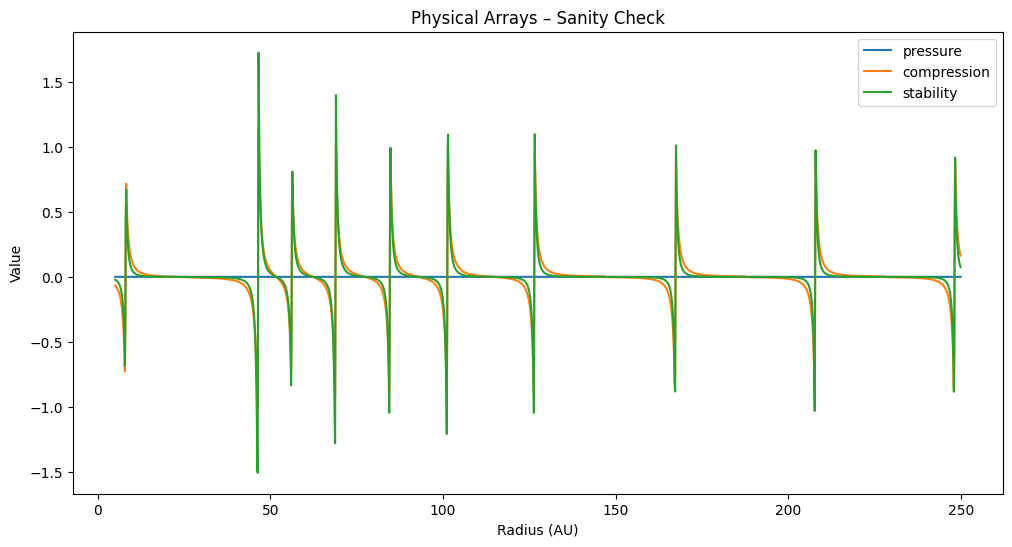

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(atlas.r_vals, atlas.pressure, label="pressure")
plt.plot(atlas.r_vals, atlas.compression, label="compression")
plt.plot(atlas.r_vals, atlas.stability, label="stability")
plt.legend()
plt.xlabel("Radius (AU)")
plt.ylabel("Value")
plt.title("Physical Arrays – Sanity Check")
plt.show()


In [8]:
import numpy as np
for r in atlas.candidates[:10]:
    idx = (np.abs(atlas.r_vals - r)).argmin()
    print(r, atlas.pressure[idx], atlas.compression[idx], atlas.stability[idx])


5.12 8.625201628386765e-05 -0.0682567546751627 -0.023725996198945776
5.37 8.041176749037193e-05 -0.07757363938773856 -0.02834721269955375
5.86 7.05316183029672e-05 -0.10317295120751238 -0.04222150651656254
7.82 4.573837429274922e-05 -0.726540285796508 -0.6838412334978227
7.94 4.468364473603317e-05 -0.38188677492424516 -0.3969695870359463
8.06 4.366883791939531e-05 0.41404970443917355 0.4284773166714685
8.19 4.2691869844162934e-05 0.715975600533042 0.6715915661508206
8.43 4.0843792003979166e-05 0.4895222392729033 0.38877838870327547
19.46 1.1646919176339463e-05 0.0030489982751356146 0.000623250926964533
22.53 9.353330291471812e-06 2.8489052834209695e-05 5.700365490949405e-06


In [9]:
atlas.planet_forces.max(), atlas.gap_mass.max(), atlas.planet_mass_inversion.max() #hidden planet indicators


(np.float64(5.003719254099425),
 np.float64(0.0028488367059777103),
 np.float64(11.145265886318436))

In [10]:
atlas.r_vals[np.argmin(atlas.v_drift)] #drift trap


np.float64(8.186593296648324)

In [6]:
import sys
sys.path.append("C:/Users/angel/Documents/Planetary_Atlas/tools")


from atlas import load_atlas
from planet_finder import find_planet_candidates

atlas = load_atlas()
planet_candidates = find_planet_candidates(atlas)
planet_candidates


,radius_AU,planet_score,planet_forces,gap_mass,planet_mass_inversion,compression
43,92.88,2.261507,0.078946,0.002707,11.145266,0.000630
31,68.98,2.099407,4.912695,0.002656,0.157011,1.021295
48,101.33,2.099182,4.970385,0.002698,0.196705,0.708775
30,68.85,2.063122,5.003719,0.002655,0.241436,0.125503
49,101.46,2.045683,4.801669,0.002698,0.166843,0.908378


In [7]:
import sys
sys.path.append("C:/Users/angel/Documents/Planetary_Atlas/tools")


from atlas import load_atlas
from hydro_planner import make_hydro_plan

atlas = load_atlas()
hydro_plan = make_hydro_plan(atlas)
hydro_plan


,radius_AU,priority_score,reason
31,68.98,1.568300,"planet-like forces, stable ring zone"
49,101.46,1.451640,"planet-like forces, stable ring zone"
32,69.10,1.395869,"planet-like forces, stable ring zone"
48,101.33,1.394804,"planet-like forces, stable ring zone"
50,101.58,1.293188,"planet-like forces, stable ring zone"
33,69.22,1.240903,"planet-like forces, stable ring zone"
51,101.70,1.147994,planet-like forces
30,68.85,1.076206,planet-like forces
47,101.21,0.811142,planet-like forces
15,46.55,0.688759,stable ring zone
